# Introduction

Although the "O" in PyGOM stands for **O**rdinary Differential Equation (ODE), the package is fundamentally built around **compartmental models**.

A compartmental model describes how entities move between different states or categories.
A defining (and simplifying) feature of such models is that rather than tracking every individual entity, we track the total quantity present in each state.
Examples from different fields include:

- Epidemiology: individuals move between disease states
- Chemistry: atoms form different molecules
- Economics: money moves between individuals or sectors
- Ecology: animals move between age classes, locations or behavioural states

These systems are described in terms of the fundamental concepts:

- The **compartments** we wish to track
- The **transitions** that move quantities between compartments
- The **events** that trigger those transitions

We shall now illustrate these ideas, making use of the simple Susceptible–Infected–Recovered (SIR) epidemic model.

## Compartments

A compartment represents a category that entities may occupy.
At any one time, the state of the system is completely determined by the populations of these compartments and is represented by the **state vector**: $\boldsymbol{y}$

```{warning}
The word "state" is also used to refer to the compartments themselves.
For example, we may talk about "disease states" S, I and R, and other times refer to the "state of the system", $\boldsymbol{y}$.
```

For example, the SIR epidemic model contains three states:

$$
\begin{aligned}
\boldsymbol{y} =
\begin{pmatrix}
S\\
I\\
R
\end{pmatrix}
\end{aligned}
$$

where S, I and R give the total number of Susceptible, Infected and Recovered indivduals respectively.

The state vector tells us the current state of the system, but to describe how the system evolves, we must define the possible movements individuals can make.

## Transitions

A transition describes how entities move to and from compartments.

### Between compartments

In these types of transition, entities move between compartments.
In the SIR model example, there are two such transitions:

- Infection, moving an individual from the S to the I compartment
- Recovery, moving an individual from the I to the R compartment

These may be represented graphically, where compartment counts are represented by nodes and transitions by directed edges, as follows:

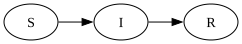

In [1]:
from graphviz import Digraph

dot = Digraph()

dot.body.extend(['rankdir=LR'])

states=['S', 'I', 'R']

for s in states:
    dot.node(s)

dot.attr(size='5,5')

dot.edge('S', 'I')
dot.edge('I', 'R')

dot

### Birth and Death processes

Transitions need not occur between two existing compartments, in fact, entities may enter or leave the modelled system.

For example, an SIR model with births and deaths might include the transitions:

- Individuals being born into the S compartment
- Individuals potentially dying whilst in any of the S, I or R compartments

To indicate these graphically, birth and death processes lack an origin or a destination state respectively:

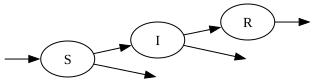

In [3]:
dot = Digraph()

dot.body.extend(['rankdir=LR'])

states=['S', 'I', 'R']

for s in states:
    dot.node(s)

dot.edge('S', 'I')
dot.edge('I', 'R')

dot.node("bornS", label="", shape='none', height="0", width="0")
dot.edge('bornS', 'S')

dot.node("deadS", label="", shape="none", height="0", width="0")
dot.edge('S', 'deadS')

dot.node("deadI", label="", shape="none", height="0", width="0")
dot.edge('I', 'deadI')

dot.node("deadR", label="", shape="none", height="0", width="0")
dot.edge('R', 'deadR')

dot

### Transition magnitudes

So far, every transition has changed the population of a compartment by exactly one unit.
This is common in epidemic models, where transitions often correspond to individual people changing state.
However, to allow for study of more general systems, PyGOM enables transitions to have arbitrary magnitude.

Non-unit transitions arise naturally in many applications.
For example, chemical reactions frequently consume and produce multiple molecules in a single reaction.

To produce an example which builds on the SIR model requires a bit of imagination.
Suppose vaccinations are administered through periodic mass-vaccination campaigns.
If each round vaccinates 100 susceptible individuals, then a vaccination transition might be represented as the transfer of 100 people from S to R.

Graphically, we indicate the magnitude by adding an annotation to the arrowhead.
Arrowheads without annotation are, of course, assumed to have magnitude of one.

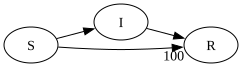

In [35]:
dot = Digraph()

dot.body.extend(['rankdir=LR'])

states=['S', 'I', 'R']

for s in states:
    dot.node(s)

dot.edge('S', 'I')
dot.edge('I', 'R')
dot.edge('S', 'R', headlabel='100')
dot

The transition still describes movement between compartments, only now the amount being transferred has changed.

## Events

A transition describes how entities move, but it does not describe when those movements occur.
To fully specify the dynamics of a compartmental model, we introduce the concept of events.
An event combines:

1) the rate describing how often it occurs
2) one or more transitions that occur when the event happens

For example,

- the infection event in the SIR model occurs at rate $\frac{\beta S I}{N}$ and triggers the $S \rightarrow I$ transition
- the recovery event occurs at rate $\gamma I$ and triggers the $I \rightarrow R$ transition
- the death event in, say, the recovered compartment occurs at a rate, $\mu R$, triggering the $R \rightarrow$ transition
- the birth event occurs at a rate, $\mu N$, triggering the $\rightarrow S$ transition
- the vaccination event occurs at rate $v S$ and triggers the transition $100 S \rightarrow 100 R$.

```{note}
For the vaccination event, we see that we might equally think about the event inducing a singular vaccination transition 100 times, rather that the magnitude being contained within the transition.
This is just a matter of convention and the one chosen for PyGOM is that the magnitude is specified with the transition.
```

In our simple SIR example with births and deaths, there is a one-to-one correspondence between transitions and events.
This makes it easy to represent graphically, where the transitions are annotated by the corresponding rate.

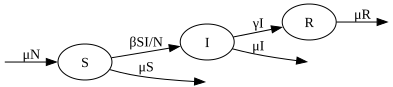

In [26]:
dot = Digraph()

dot.body.extend(['rankdir=LR'])

states=['S', 'I', 'R']

for s in states:
    dot.node(s)

dot.edge('S', 'I', label='&beta;SI/N')
dot.edge('I', 'R', label='&gamma;I')

dot.node("bornS", label="", shape="none", height="0", width="0")
dot.edge('bornS', 'S', label="&mu;N")

dot.node("deadS", label="", shape="none", height="0", width="0")
dot.edge('S', 'deadS', label="&mu;S")

dot.node("deadI", label="", shape="none", height="0", width="0")
dot.edge('I', 'deadI', label="&mu;I")

dot.node("deadR", label="", shape="none", height="0", width="0")
dot.edge('R', 'deadR', label="&mu;R")

dot

### Multi transition events

More generally, a single event may cause multiple transitions to occur simultaneously.
For instance, suppose we wish to track both the cumulative number of infections and the resources used in an epidemic.
We introduce two additional compartments:

- $I_{tot}$: Cumulative infections
- $M$: Cumulative monetary cost

Now, whenever infection occurs, three transitions occur simultaneously:

- An individual moves from S to I
- $I_{tot}$ increases by 1
- $M$ incrases by the cost, $c$

This can be shown graphically as follows:

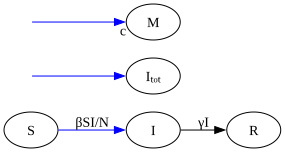

In [ ]:
from graphviz import Digraph

dot = Digraph()

dot.body.extend(['rankdir=LR'])

states=['S', 'I', 'R']

for s in states:
    dot.node(s)

dot.edge('S', 'I', label='&beta;SI/N', color="blue")
dot.edge('I', 'R', label='&gamma;I')

dot.node("I0", label="", shape="none", height="0", width="0")
dot.edge('I0', 'Iₜₒₜ', color="blue")

dot.node("M0", label="", shape="none", height="0", width="0")
dot.edge('M0', 'M', color="blue", headlabel='c')

dot

We indicate the simulteneity of the infection and cost transitions by the shared blue colour (note that multiple transitions in the default colour, black, are not implied to be simultaneous).
Since transitions belonging to a common event have the same underlying rate, only one rate needs be specified on the graph.

This distinction between transitions and events is fundamental to the way PyGOM represents compartmental models.

<!-- ```{note}

### Reactions vs Events

For epidemiological systems, our interpretation of transitions as material moving between states is a comfortable one.
However, chemical reactions, for example, often involve several compartments being consumed and produced simultaneously.

For example, in the synthesis of water,

$2 H_2 + O_2 \rightarrow 2 H_2 O$

Chemists may be used to regarding the transition as being a state change of [-2, -1, +2].

In the formalism we have layed out, the event consists of 3 transitions: deaths of two hydrogen molecules, death of one oxygen molecule and birth of two two molecules.

Since PyGOM is geared towards epi rather than chemistry, we are ok with this.
``` -->

# Summary

A compartmental model in PyGOM is defined by:

1) a collection of compartments
2) a collection of transitions describing permitted movements
3) a collection of events, each consisting of
    - an event rate
    - one or more transitions

These concepts are sufficient to define the structure of a model.
In the next section, we show how they can be represented mathematically and how the resulting representation may be solved.